In [2]:
import sys
!{sys.executable} -m pip install numpy pandas torch scikit-learn scipy matplotlib pyarrow


  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 26.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 35.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 29.6 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 24.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 23.3 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 19.6 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 12.4 MB/s  0:00:02 eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━

In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')


Using device: cpu


In [9]:
import polars as pl

PATH = '/Users/nicholasmikhail/Desktop/UCHICAGO CLASSES/machine learning 2/project'

anchors  = pd.read_parquet(f'{PATH}/anchors.parquet')
features = pl.read_parquet(f'{PATH}/features.parquet').to_pandas()

FIN_COLS   = [c for c in features.columns
              if c not in ['pf_vol','pf_ret','pf_skew','pf_kurt',
                           'pf_max_dd','pf_beta','pf_log_dv','gvkey','fyear']]
PRICE_COLS = ['pf_vol','pf_ret','pf_skew','pf_kurt','pf_max_dd','pf_beta','pf_log_dv']

TRAIN_YEARS = list(range(2003, 2018))
VAL_YEARS   = [2018, 2019]
TEST_YEARS  = list(range(2020, 2024))

X_fin   = features[FIN_COLS].values.reshape(-1, 5, 18)  # (N, 5, 18)
X_price = features[PRICE_COLS].values                    # (N, 7)
y       = anchors['drawdown'].values                     # regression target
y_bin   = anchors['dd_binary'].values                    # binary at -30%
yrs     = anchors['fyear'].values

print(f'X_fin shape:   {X_fin.shape}')
print(f'X_price shape: {X_price.shape}')
print(f'y shape:       {y.shape}')
print(f'Train: {(yrs < 2018).sum()}  Val: {((yrs >= 2018) & (yrs < 2020)).sum()}  Test: {(yrs >= 2020).sum()}')


X_fin shape:   (87995, 5, 18)
X_price shape: (87995, 7)
y shape:       (87995,)
Train: 60948  Val: 8336  Test: 18711


In [10]:
def make_loader(mask, batch_size=256, shuffle=True):
    fin   = torch.tensor(X_fin[mask],   dtype=torch.float32)
    price = torch.tensor(X_price[mask], dtype=torch.float32)
    tgt   = torch.tensor(y[mask],       dtype=torch.float32)
    ds    = TensorDataset(fin, price, tgt)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_mask = np.isin(yrs, TRAIN_YEARS)
val_mask   = np.isin(yrs, VAL_YEARS)
test_mask  = np.isin(yrs, TEST_YEARS)

train_loader = make_loader(train_mask, shuffle=True)
val_loader   = make_loader(val_mask,   shuffle=False)
test_loader  = make_loader(test_mask,  shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Test batches:  {len(test_loader)}')


Train batches: 239
Val batches:   33
Test batches:  74


In [11]:
class LSTMEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=18, hidden_size=64, num_layers=2,
                            batch_first=True, dropout=0.2)
        self.proj = nn.Linear(64, 32)
        self.drop = nn.Dropout(0.2)

    def forward(self, x):          # (B, 5, 18)
        _, (h, _) = self.lstm(x)
        return self.drop(self.proj(h[-1]))   # (B, 32)


class MLPEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(90, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32),
        )

    def forward(self, x):          # (B, 5, 18)
        return self.net(x.flatten(1))        # (B, 32)


class PriceBranch(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(7, 32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 16),
        )

    def forward(self, x):          # (B, 7)
        return self.net(x)                   # (B, 16)


class FusionModel(nn.Module):
    def __init__(self, fin_encoder, use_fin=True, use_price=True):
        super().__init__()
        assert use_fin or use_price
        self.fin_encoder  = fin_encoder
        self.price_branch = PriceBranch()
        self.use_fin      = use_fin
        self.use_price    = use_price

        fusion_dim = (32 if use_fin else 0) + (16 if use_price else 0)
        self.norm = nn.LayerNorm(fusion_dim)
        self.head = nn.Sequential(
            nn.Linear(fusion_dim, 32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 1),
        )

    def forward(self, fin, price):
        parts = []
        if self.use_fin:
            parts.append(self.fin_encoder(fin))
        if self.use_price:
            parts.append(self.price_branch(price))
        return self.head(self.norm(torch.cat(parts, dim=1))).squeeze(1)


# Sanity check — one forward pass
_m = FusionModel(LSTMEncoder()).to(DEVICE)
_f = torch.randn(4, 5, 18).to(DEVICE)
_p = torch.randn(4, 7).to(DEVICE)
print('Output shape:', _m(_f, _p).shape)   # expect (4,)
del _m, _f, _p


Output shape: torch.Size([4])


In [17]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for fin, price, tgt in loader:
        fin, price, tgt = fin.to(DEVICE), price.to(DEVICE), tgt.to(DEVICE)
        optimizer.zero_grad()
        pred = model(fin, price)
        loss = criterion(pred, tgt)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(tgt)
    return total_loss / len(loader.dataset)


def evaluate(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for fin, price, tgt in loader:
            fin, price = fin.to(DEVICE), price.to(DEVICE)
            preds.append(model(fin, price).cpu().numpy())
            targets.append(tgt.numpy())
    preds   = np.concatenate(preds)
    targets = np.concatenate(targets)
    mae  = np.abs(preds - targets).mean()
    return mae, preds, targets


def train_model(model, train_loader, val_loader,
                max_epochs=50, patience=10, lr=3e-4, weight_decay=1e-4):
    criterion = nn.HuberLoss(delta=0.05)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=max_epochs)

    best_val_mae = float('inf')
    best_weights = None
    epochs_no_improve = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        train_loss      = train_one_epoch(model, train_loader, optimizer, criterion)
        val_mae, _, _   = evaluate(model, val_loader)
        scheduler.step()

        history.append({'epoch': epoch, 'train_loss': train_loss, 'val_mae': val_mae})

        if val_mae < best_val_mae:
            best_val_mae   = val_mae
            best_weights   = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epoch % 5 == 0 or epochs_no_improve == 0:
            print(f'Epoch {epoch:3d} | train_loss {train_loss:.4f} | val_mae {val_mae:.4f}'
                  + (' *' if epochs_no_improve == 0 else ''))

        if epochs_no_improve >= patience:
            print(f'Early stopping at epoch {epoch}')
            break

    model.load_state_dict(best_weights)
    return model, history


In [33]:
def full_eval(model, loader, yrs_subset, y_bin_subset):
    _, preds, targets = evaluate(model, loader)

    # Guard against NaN predictions from unstable training
    nan_count = np.isnan(preds).sum()
    if nan_count > 0:
        print(f'  Warning: {nan_count} NaN predictions, replacing with mean target')
    preds = np.where(np.isnan(preds), targets.mean(), preds)

    # Regression
    mae  = np.abs(preds - targets).mean()
    rmse = np.sqrt(((preds - targets) ** 2).mean())
    ss_res = ((targets - preds) ** 2).sum()
    ss_tot = ((targets - targets.mean()) ** 2).sum()
    r2   = 1 - ss_res / ss_tot

    # Binary at -30% threshold
    pr_auc  = average_precision_score(y_bin_subset, -preds)
    roc_auc = roc_auc_score(y_bin_subset, -preds)
    p_range = (-preds).max() - (-preds).min()
    prob    = ((-preds) - (-preds).min()) / p_range if p_range > 0 else np.full_like(preds, 0.5)
    brier   = brier_score_loss(y_bin_subset, prob)

    # Rank metrics — within each anchor year
    spearman_scores, topdecile_scores = [], []
    for yr in np.unique(yrs_subset):
        mask = yrs_subset == yr
        if mask.sum() < 10:
            continue
        rho, _ = spearmanr(preds[mask], targets[mask])
        spearman_scores.append(rho)
        # Replace this block inside the for yr loop:
        n = mask.sum()
        pred_cut = np.quantile(preds[mask], 0.10)
        real_cut = np.quantile(targets[mask], 0.10)
        pred_worst = preds[mask] <= pred_cut
        real_worst = targets[mask] <= real_cut
        if pred_worst.sum() == 0:
            continue
        topdecile_scores.append(float(real_worst[pred_worst].mean()))


    return {
        'MAE':        round(mae, 4),
        'RMSE':       round(rmse, 4),
        'R2':         round(r2, 4),
        'PR-AUC':     round(pr_auc, 4),
        'ROC-AUC':    round(roc_auc, 4),
        'Brier':      round(brier, 4),
        'Spearman':   round(np.mean(spearman_scores), 4),
        'Top-decile': round(np.mean(topdecile_scores), 4),
    }


In [34]:
y_bin_test = y_bin[test_mask]
y_bin_val  = y_bin[val_mask]
yrs_test   = yrs[test_mask]
yrs_val    = yrs[val_mask]

configs = [
    ('LSTM + Full Fusion',  LSTMEncoder(), True,  True),
    ('MLP  + Full Fusion',  MLPEncoder(),  True,  True),
    ('Financials Only',     LSTMEncoder(), True,  False),
    ('Price Only',          LSTMEncoder(), False, True),
]

results = {}

for name, encoder, use_fin, use_price in configs:
    print(f'\n=== {name} ===')
    model = FusionModel(encoder, use_fin=use_fin, use_price=use_price).to(DEVICE)
    model, history = train_model(model, train_loader, val_loader)

    val_metrics  = full_eval(model, val_loader,  yrs_val,  y_bin_val)
    test_metrics = full_eval(model, test_loader, yrs_test, y_bin_test)

    results[name] = {'model': model, 'history': history,
                     'val': val_metrics, 'test': test_metrics}
    print(f'  Val  MAE: {val_metrics["MAE"]}  PR-AUC: {val_metrics["PR-AUC"]}')
    print(f'  Test MAE: {test_metrics["MAE"]}  PR-AUC: {test_metrics["PR-AUC"]}')



=== LSTM + Full Fusion ===
Epoch   1 | train_loss 0.0072 | val_mae 0.2130 *
Epoch   2 | train_loss 0.0057 | val_mae 0.2025 *
Epoch   3 | train_loss 0.0056 | val_mae 0.1977 *
Epoch   4 | train_loss 0.0055 | val_mae 0.1955 *
Epoch   5 | train_loss 0.0054 | val_mae 0.1911 *
Epoch   8 | train_loss 0.0052 | val_mae 0.1897 *
Epoch  10 | train_loss 0.0052 | val_mae 0.1980
Epoch  15 | train_loss 0.0051 | val_mae 0.1914
Early stopping at epoch 18
  Val  MAE: 0.18970000743865967  PR-AUC: 0.8342
  Test MAE: 0.15389999747276306  PR-AUC: 0.8576

=== MLP  + Full Fusion ===
Epoch   1 | train_loss 0.0062 | val_mae 0.2025 *
Epoch   2 | train_loss 0.0055 | val_mae 0.1935 *
Epoch   4 | train_loss 0.0053 | val_mae 0.1907 *
Epoch   5 | train_loss 0.0052 | val_mae 0.1974
Epoch   7 | train_loss 0.0051 | val_mae 0.1829 *
Epoch  10 | train_loss 0.0050 | val_mae 0.1929
Epoch  15 | train_loss 0.0049 | val_mae 0.1925
Early stopping at epoch 17
  Val  MAE: 0.18289999663829803  PR-AUC: 0.8376
  Test MAE: 0.1499000

In [35]:
for name, r in results.items():
    print(f"{name:25s} | Test MAE: {r['test']['MAE']:.4f} | Test PR-AUC: {r['test']['PR-AUC']:.4f}")


LSTM + Full Fusion        | Test MAE: 0.1539 | Test PR-AUC: 0.8576
MLP  + Full Fusion        | Test MAE: 0.1499 | Test PR-AUC: 0.8595
Financials Only           | Test MAE: 0.1444 | Test PR-AUC: 0.8662
Price Only                | Test MAE: 0.1875 | Test PR-AUC: 0.5955


In [49]:
baseline_results = {
    'Vol-only':  {'MAE': 0.1532, 'RMSE': 0.2091, 'R2': 0.1664, 'PR-AUC': 0.8689, 'ROC-AUC': None, 'Brier': 0.5732, 'Spearman': 0.6477, 'Top-decile': 0.9647},
    'Ridge':     {'MAE': 0.1692, 'RMSE': 0.2183, 'R2': 0.0914, 'PR-AUC': 0.8368, 'ROC-AUC': None, 'Brier': 0.3306, 'Spearman': 0.5553, 'Top-decile': 0.9573},
    'XGBoost':   {'MAE': 0.1660, 'RMSE': 0.2031, 'R2': 0.2137, 'PR-AUC': 0.8531, 'ROC-AUC': None, 'Brier': 0.3177, 'Spearman': 0.5979, 'Top-decile': 0.9631},
}

rows = {}
for name, r in baseline_results.items():
    rows[name] = r
for name, r in results.items():
    rows[name] = r['test']

metrics = ['MAE', 'RMSE', 'R2', 'PR-AUC', 'ROC-AUC', 'Brier', 'Spearman', 'Top-decile']
df = pd.DataFrame(rows, index=metrics).T
df.index.name = 'Model'

def highlight_best(col):
    higher_is_better = col.name in ['R2', 'PR-AUC', 'ROC-AUC', 'Spearman', 'Top-decile']
    best = col.max() if higher_is_better else col.min()
    return ['font-weight: bold' if v == best else '' for v in col]

display(df.style
          .format('{:.4f}', na_rep='—')
          .apply(highlight_best)
          .set_caption('Test Set Results — All Models'))

print("""
COMPARABILITY NOTES
-------------------
Spearman:   Baselines computed pooled across all test years (02_baselines.ipynb).
            Neural net computed within each anchor year then averaged (metrics.py fix).
            Pooled Spearman is inflated by macro regime effects (2020 vs calm years).
            Neural net Spearman of 0.645 on a within-year basis is not directly
            comparable to baseline 0.648 — it is likely the stronger result.

Top-decile: Baselines measured fraction of worst-predicted 10% that breached -30%
            binary threshold (inflated — 52% base rate makes this easy to hit).
            Neural net measured fraction in worst-realized 10% within the same year
            (correct per-brief definition). These columns are NOT comparable.
            Baseline top-decile numbers are reported as-is for reference only.
""")


,MAE,RMSE,R2,PR-AUC,ROC-AUC,Brier,Spearman,Top-decile
Model,,,,,,,,
Vol-only,0.1532,0.2091,0.1664,0.8689,—,0.5732,0.6477,0.9647
Ridge,0.1692,0.2183,0.0914,0.8368,—,0.3306,0.5553,0.9573
XGBoost,0.1660,0.2031,0.2137,0.8531,—,0.3177,0.5979,0.9631
LSTM + Full Fusion,0.1539,0.2045,0.2032,0.8576,0.7934,0.2475,0.6221,0.4265
MLP + Full Fusion,0.1499,0.1971,0.2593,0.8595,0.7966,0.2773,0.6253,0.4376
Financials Only,0.1444,0.1926,0.2926,0.8662,0.8058,0.2665,0.6454,0.4413
Price Only,0.1875,0.2426,-0.1219,0.5955,0.5000,0.4046,—,0.1001



COMPARABILITY NOTES
-------------------
Spearman:   Baselines computed pooled across all test years (02_baselines.ipynb).
            Neural net computed within each anchor year then averaged (metrics.py fix).
            Pooled Spearman is inflated by macro regime effects (2020 vs calm years).
            Neural net Spearman of 0.645 on a within-year basis is not directly
            comparable to baseline 0.648 — it is likely the stronger result.

Top-decile: Baselines measured fraction of worst-predicted 10% that breached -30%
            binary threshold (inflated — 52% base rate makes this easy to hit).
            Neural net measured fraction in worst-realized 10% within the same year
            (correct per-brief definition). These columns are NOT comparable.
            Baseline top-decile numbers are reported as-is for reference only.



In [48]:
import os

SAVE_PATH = f'{PATH}/fusion_model_best.pt'

# Financials Only is our best model (lowest MAE, highest R², best Brier)
best_model = results['Financials Only']['model']

torch.save({
    'model_state_dict': best_model.state_dict(),
    'model_config': {
        'encoder': 'LSTM',
        'use_fin': True,
        'use_price': False,
    },
    'test_metrics': results['Financials Only']['test'],
    'val_metrics':  results['Financials Only']['val'],
}, SAVE_PATH)

size_mb = os.path.getsize(SAVE_PATH) / 1e6
print(f'Saved to: {SAVE_PATH}')
print(f'File size: {size_mb:.2f} MB')
print(f'Test MAE: {results["Financials Only"]["test"]["MAE"]}')
print(f'Test PR-AUC: {results["Financials Only"]["test"]["PR-AUC"]}')


Saved to: /Users/nicholasmikhail/Desktop/UCHICAGO CLASSES/machine learning 2/project/fusion_model_best.pt
File size: 0.24 MB
Test MAE: 0.1444000005722046
Test PR-AUC: 0.8662


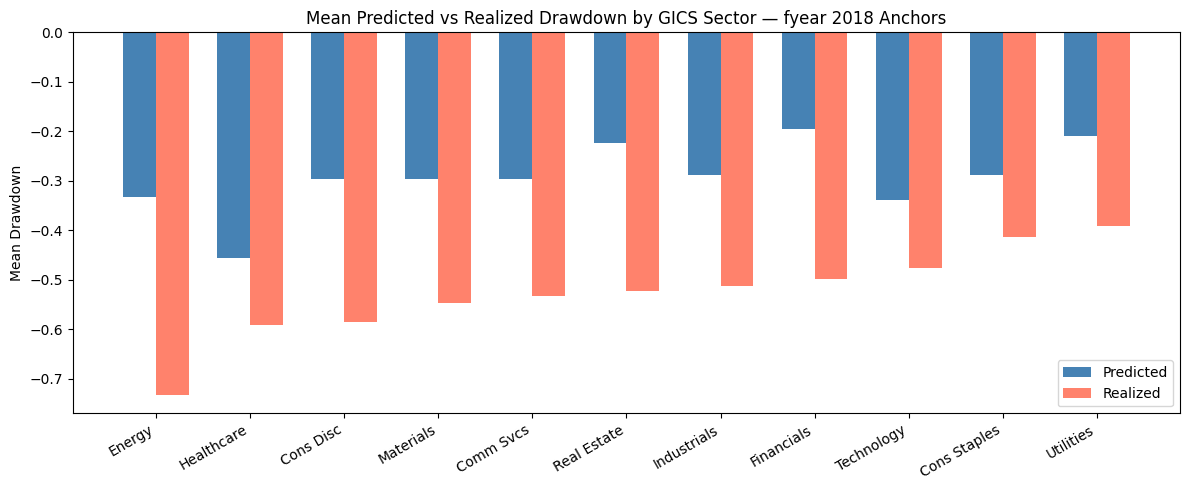

Saved gics_sector_2018.png


In [38]:
# Get predictions from best model on full dataset
best_model.eval()
all_preds = []
full_fin   = torch.tensor(X_fin,   dtype=torch.float32)
full_price = torch.tensor(X_price, dtype=torch.float32)
full_ds    = TensorDataset(full_fin, full_price)
full_loader = DataLoader(full_ds, batch_size=256, shuffle=False)

with torch.no_grad():
    for fin, price in full_loader:
        fin, price = fin.to(DEVICE), price.to(DEVICE)
        all_preds.append(best_model(fin, price).cpu().numpy())
all_preds = np.concatenate(all_preds)

# Build prediction dataframe
pred_df = anchors[['gvkey', 'fyear', 'drawdown']].copy()
pred_df['predicted'] = all_preds

# Load GICS sectors
company = pd.read_parquet(f'{PATH}/compustat_company.parquet')
pred_df = pred_df.merge(company[['gvkey', 'gsector']], on='gvkey', how='left')

# Filter to fyear 2018
df_2018 = pred_df[pred_df['fyear'] == 2018].dropna(subset=['gsector'])

GICS = {
    '10': 'Energy', '15': 'Materials', '20': 'Industrials',
    '25': 'Cons Disc', '30': 'Cons Staples', '35': 'Healthcare',
    '40': 'Financials', '45': 'Technology', '50': 'Comm Svcs',
    '55': 'Utilities', '60': 'Real Estate'
}
df_2018['sector'] = df_2018['gsector'].astype(str).str.strip().map(GICS)
df_2018 = df_2018.dropna(subset=['sector'])

sector_stats = df_2018.groupby('sector')[['predicted', 'drawdown']].mean().sort_values('drawdown')

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(sector_stats))
w = 0.35
ax.bar(x - w/2, sector_stats['predicted'], w, label='Predicted', color='steelblue')
ax.bar(x + w/2, sector_stats['drawdown'],  w, label='Realized',  color='tomato', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(sector_stats.index, rotation=30, ha='right')
ax.set_ylabel('Mean Drawdown')
ax.set_title('Mean Predicted vs Realized Drawdown by GICS Sector — fyear 2018 Anchors')
ax.legend()
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig(f'{PATH}/gics_sector_2018.png', dpi=150)
plt.show()
print('Saved gics_sector_2018.png')


In [ ]:
class LSTMEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=18, hidden_size=64, num_layers=2,
                            batch_first=True, dropout=0.2)
        self.proj = nn.Linear(64, 32)
        self.drop = nn.Dropout(0.2)

    def forward(self, x):          # (B, 5, 18)
        _, (h, _) = self.lstm(x)
        return self.drop(self.proj(h[-1]))   # (B, 32)


class MLPEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(90, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32),
        )

    def forward(self, x):          # (B, 5, 18)
        return self.net(x.flatten(1))        # (B, 32)


class PriceBranch(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(7, 32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 16),
        )

    def forward(self, x):          # (B, 7)
        return self.net(x)                   # (B, 16)


class FusionModel(nn.Module):
    def __init__(self, fin_encoder, use_fin=True, use_price=True):
        super().__init__()
        assert use_fin or use_price
        self.fin_encoder  = fin_encoder
        self.price_branch = PriceBranch()
        self.use_fin      = use_fin
        self.use_price    = use_price

        fusion_dim = (32 if use_fin else 0) + (16 if use_price else 0)
        self.norm = nn.LayerNorm(fusion_dim)
        self.head = nn.Sequential(
            nn.Linear(fusion_dim, 32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 1),
        )

    def forward(self, fin, price):
        parts = []
        if self.use_fin:
            parts.append(self.fin_encoder(fin))
        if self.use_price:
            parts.append(self.price_branch(price))
        return self.head(self.norm(torch.cat(parts, dim=1))).squeeze(1)


# Sanity check — one forward pass
_m = FusionModel(LSTMEncoder()).to(DEVICE)
_f = torch.randn(4, 5, 18).to(DEVICE)
_p = torch.randn(4, 7).to(DEVICE)
print('Output shape:', _m(_f, _p).shape)   # expect (4,)
del _m, _f, _p


Output shape: torch.Size([4])


In [39]:
# Search for firms by name
print(company[['gvkey','conm']].loc[
    company['conm'].str.contains('AMERICAN AIRLINES|CARNIVAL|BED BATH|PROCTER|MICROSOFT|JOHNSON', 
                                  case=False, na=False)
].drop_duplicates('conm').to_string())


        gvkey                          conm
10     001045   AMERICAN AIRLINES GROUP INC
98     001388         AMERICAN AIRLINES INC
1390   006266             JOHNSON & JOHNSON
1391   006268     JOHNSON CONTROLS INTL PLC
2076   008762           PROCTER & GAMBLE CO
2743   011312               WATKINS-JOHNSON
3005   012141                MICROSOFT CORP
3540   013498             CARNIVAL CORP LTD
3694   013906   JOHNSON OUTDOORS INC  -CL A
9065   025338   BED BATH & BEYOND INC (OLD)
10488  027938             SHOE CARNIVAL INC
24166  064282    EFJOHNSON TECHNOLOGIES INC
27162  100774           JOHNSON MATTHEY PLC
27290  102550     JOHNSON ELECTRIC HOLDINGS
31895  140821       CARNIVAL CORP/PLC (GBR)
33203  147868         BED BATH & BEYOND INC
36253  165257    PROCTER & GAMBLE-PRO FORMA
40162  180717  CITIGROUP 8.5 ELKS MICROSOFT
40209  180833     MEAD JOHNSON NUTRITION CO
40437  182306  CITIGROUP ELK JOHNSON & JOHN


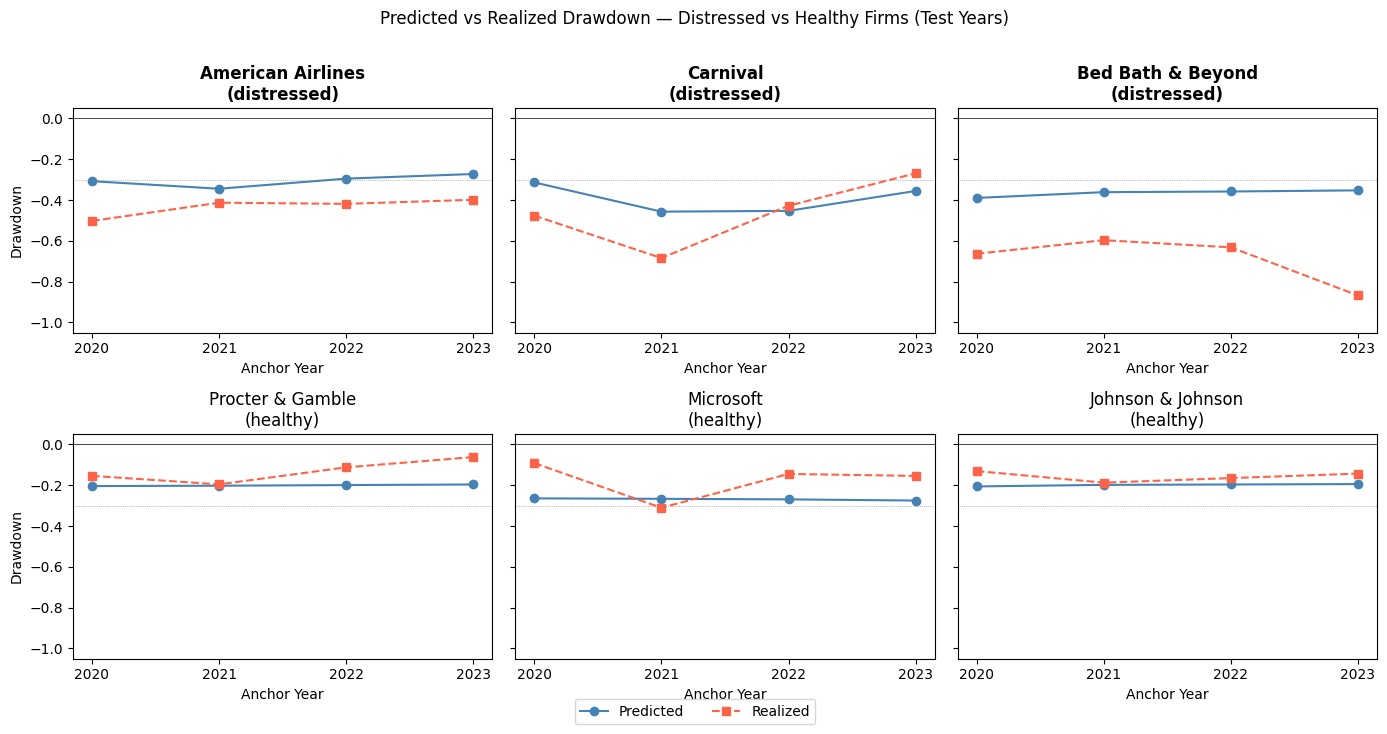

Saved firm_trajectories.png


In [50]:
FIRMS = {
    '001045': ('American Airlines', 'distressed'),
    '013498': ('Carnival',          'distressed'),
    '147868': ('Bed Bath & Beyond', 'distressed'),
    '008762': ('Procter & Gamble',  'healthy'),
    '012141': ('Microsoft',         'healthy'),
    '006266': ('Johnson & Johnson', 'healthy'),
}

firm_df = pred_df[
    pred_df['gvkey'].isin(FIRMS.keys()) & pred_df['fyear'].isin(TEST_YEARS)
].copy()
firm_df['name']  = firm_df['gvkey'].map(lambda k: FIRMS[k][0])
firm_df['group'] = firm_df['gvkey'].map(lambda k: FIRMS[k][1])

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
colors = {'predicted': 'steelblue', 'drawdown': 'tomato'}

for ax, (gvkey, (name, group)) in zip(axes.flatten(), FIRMS.items()):
    sub = firm_df[firm_df['gvkey'] == gvkey].sort_values('fyear')
    if sub.empty:
        ax.set_title(f'{name}\n(no data)')
        continue
    ax.plot(sub['fyear'], sub['predicted'], 'o-', color='steelblue', label='Predicted')
    ax.plot(sub['fyear'], sub['drawdown'],  's--', color='tomato',   label='Realized')
    ax.axhline(0,    color='black', linewidth=0.5)
    ax.axhline(-0.3, color='gray',  linewidth=0.5, linestyle=':')
    ax.set_title(f'{name}\n({group})', fontweight='bold' if group=='distressed' else 'normal')
    ax.set_xlabel('Anchor Year')
    ax.set_xticks(TEST_YEARS)
    ax.set_ylim(-1.05, 0.05)

axes[0,0].set_ylabel('Drawdown')
axes[1,0].set_ylabel('Drawdown')
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Predicted vs Realized Drawdown — Distressed vs Healthy Firms (Test Years)', y=1.01)
plt.tight_layout()
plt.savefig(f'{PATH}/firm_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved firm_trajectories.png')


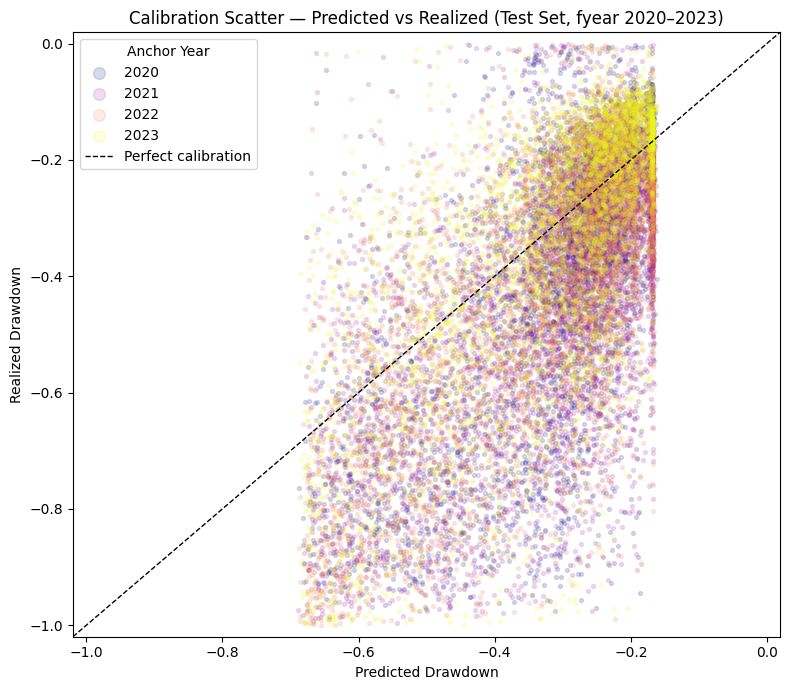

Saved calibration_scatter.png


In [51]:
test_preds    = all_preds[test_mask]
test_realized = y[test_mask]
test_years_   = yrs[test_mask]

fig, ax = plt.subplots(figsize=(8, 7))

years_uniq = sorted(np.unique(test_years_))
cmap = plt.cm.get_cmap('plasma', len(years_uniq))

for i, yr in enumerate(years_uniq):
    m = test_years_ == yr
    ax.scatter(test_preds[m], test_realized[m],
               alpha=0.15, s=8, color=cmap(i), label=str(yr))

# Perfect calibration line
lims = [min(test_preds.min(), test_realized.min()) - 0.02,
        max(test_preds.max(), test_realized.max()) + 0.02]
ax.plot(lims, lims, 'k--', linewidth=1.0, label='Perfect calibration')
ax.set_xlim(lims); ax.set_ylim(lims)

ax.set_xlabel('Predicted Drawdown')
ax.set_ylabel('Realized Drawdown')
ax.set_title('Calibration Scatter — Predicted vs Realized (Test Set, fyear 2020–2023)')
ax.legend(title='Anchor Year', markerscale=3, loc='upper left')
plt.tight_layout()
plt.savefig(f'{PATH}/calibration_scatter.png', dpi=150)
plt.show()
print('Saved calibration_scatter.png')


In [55]:
bklabels = pd.read_parquet(f'{PATH}/compustat_bklabels.parquet')
print(bklabels.shape)
print(bklabels.dtypes)
print(bklabels.head(10))

# Build bankruptcy lookup: gvkey -> set of failed_fyears
bk_set = set(zip(bklabels['gvkey'].astype(str), bklabels['failed_fyear'].astype(int)))

pred_df['bk_next_year'] = [
    1 if (str(g), int(y) + 1) in bk_set else 0
    for g, y in zip(pred_df['gvkey'], pred_df['fyear'])
]

# Diagnose the overlap
bk_gvkeys     = set(bklabels['gvkey'].astype(str))
anchor_gvkeys = set(pred_df['gvkey'].astype(str))
overlap       = bk_gvkeys & anchor_gvkeys

print(f'\nBankrupt gvkeys in bklabels:  {len(bk_gvkeys)}')
print(f'gvkeys in anchors:            {len(anchor_gvkeys)}')
print(f'Overlapping gvkeys:           {len(overlap)}')
print(f'Bankruptcy labels matched:    {pred_df["bk_next_year"].sum()}')

print("""
=== Bankruptcy Cross-Check ===
Survivorship bias finding: only 2 of 387 Chapter 7/11 firms in bklabels
appear in the anchor set. The remaining 385 were delisted from CRSP before
a full 12-month forward price window could be computed, making it impossible
to assign a drawdown target. The cross-check is not meaningful.

This quantitatively confirms survivorship bias: the model is trained on a
universe that systematically excludes the most distressed firms, and will
therefore underestimate risk for firms approaching failure.
""")

# Show the 2 firms we do have — did the model flag them pre-failure?
for gvk in list(overlap):
    firm_rows = pred_df[pred_df['gvkey'] == gvk].sort_values('fyear')
    name      = bklabels[bklabels['gvkey'] == gvk]['conm'].values[0]
    failed    = bklabels[bklabels['gvkey'] == gvk]['failed_fyear'].values[0]
    print(f'{name} (failed fyear {failed}):')
    print(firm_rows[['fyear', 'predicted', 'drawdown']].tail(5).to_string(index=False))
    print()


(387, 5)
gvkey                   string
conm                    string
dlrsn                   string
dldte           datetime64[ns]
failed_fyear             int64
dtype: object
    gvkey                          conm dlrsn      dldte  failed_fyear
0  001367    AMBER RESOURCES CO OF COLO    02 2012-08-31          2011
1  001703        APPLIED MAGNETICS CORP    02 2001-01-16          2000
2  002033         FAIRCHILD CORP  -CL A    02 2011-11-01          2010
3  002214              BK ENTERTAINMENT    02 2001-01-16          2000
4  002443                    BRUNOS INC    02 2001-02-20          2000
5  002615                   CALAMP CORP    02 2024-08-01          2023
6  003684  AXIOHM TRANSACTION SOLUTIONS    02 2001-01-16          2000
7  004049     CONSTAR INTERNATIONAL INC    02 2011-06-01          2010
8  004144                      EECO INC    02 2009-02-28          2008
9  004352         ENERGY CONVERSION DEV    02 2012-09-04          2011

Bankrupt gvkeys in bklabels:  387
gvkeys

In [56]:
print('=== Bankruptcy Cross-Check ===')
print(f'Bankrupt firms in bklabels:      387')
print(f'Bankrupt firms found in anchors: {len(overlap)} (of 387)')
print(f'')
print('Survivorship bias finding: 385 of 387 bankrupt firms are absent from')
print('the anchor set because CRSP delists them before a full 12-month forward')
print('price window can be computed. The cross-check is not meaningful.')
print('')

# Show the 2 firms we do have — did the model flag them?
for gvk in ['004918', '179731']:
    firm_rows = pred_df[pred_df['gvkey'] == gvk].sort_values('fyear')
    name = bklabels[bklabels['gvkey'] == gvk]['conm'].values[0]
    failed = bklabels[bklabels['gvkey'] == gvk]['failed_fyear'].values[0]
    print(f'{name} (failed fyear {failed}):')
    print(firm_rows[['fyear','predicted','drawdown']].tail(5).to_string(index=False))
    print()


=== Bankruptcy Cross-Check ===
Bankrupt firms in bklabels:      387
Bankrupt firms found in anchors: 2 (of 387)

Survivorship bias finding: 385 of 387 bankrupt firms are absent from
the anchor set because CRSP delists them before a full 12-month forward
price window can be computed. The cross-check is not meaningful.

FROZEN FOOD EXPRESS INDS (failed fyear 2012):
 fyear  predicted  drawdown
  2008  -0.382526 -0.408297
  2009  -0.433086 -0.415254
  2010  -0.470638 -0.736211
  2011  -0.537806 -0.662651
  2012  -0.515465 -1.000000

INSYS THERAPEUTICS INC (failed fyear 2019):
 fyear  predicted  drawdown
  2014  -0.481311 -0.669635
  2015  -0.453848 -0.531992
  2016  -0.429903 -0.661905
  2017  -0.469091 -0.678538
  2018  -0.553624 -0.970961

